# Part 2: Can we omit some controls? (7 points)

This notebook analyzes a DAG with multiple control variables to determine the minimal sufficient set for estimating the causal effect of X on Y.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import collections
import collections.abc

# Backward compatibility for causalgraphicalmodels (expects collections.Iterable)
if not hasattr(collections, "Iterable"):
    collections.Iterable = collections.abc.Iterable

from causalgraphicalmodels import CausalGraphicalModel
import statsmodels.api as sm
from scipy import stats

# Set random seed for reproducibility
np.random.seed(42)
plt.style.use('seaborn-v0_8')

# Create output directory if it doesn't exist
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## DAG Specification

We need to create a DAG with the following causal relationships:
- $X \rightarrow Y$
- $Z_1 \rightarrow X$, $Z_1 \rightarrow Y$
- $Z_2 \rightarrow X$, $Z_2 \rightarrow Y$
- $Z_3 \rightarrow Z_2$, $Z_3 \rightarrow Y$

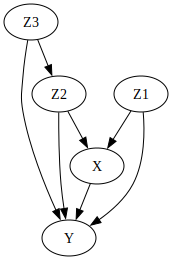

In [24]:
# Create and visualize the DAG
dag = CausalGraphicalModel(
    nodes=['Z3', 'Z1', 'Z2', 'X', 'Y'],
    edges=[
        ('X', 'Y'),      # Direct effect of X on Y
        ('Z1', 'X'),     # Z1 affects X
        ('Z1', 'Y'),     # Z1 affects Y
        ('Z2', 'X'),     # Z2 affects X
        ('Z2', 'Y'),     # Z2 affects Y
        ('Z3', 'Z2'),    # Z3 affects Z2
        ('Z3', 'Y')      # Z3 affects Y
    ]
)

# Draw the DAG
from graphviz import Source
Source(dag.draw().source)

## Data Simulation

Following the lab convention where each causal arrow represents a unit effect, we simulate:
- $Z_3 = \varepsilon_{Z_3}$
- $Z_1 = \varepsilon_{Z_1}$  
- $Z_2 = Z_3 + \varepsilon_{Z_2}$
- $X = Z_1 + Z_2 + \varepsilon_X$
- $Y = X + Z_1 + Z_2 + Z_3 + \varepsilon_Y$

In [25]:
# Set sample size
n = 10000

# Generate exogenous variables (error terms)
eps_Z3 = np.random.normal(0, 1, n)
eps_Z1 = np.random.normal(0, 1, n)
eps_Z2 = np.random.normal(0, 1, n)
eps_X = np.random.normal(0, 1, n)
eps_Y = np.random.normal(0, 1, n)

# Generate endogenous variables following the DAG structure
Z3 = eps_Z3
Z1 = eps_Z1
Z2 = Z3 + eps_Z2  # Z3 -> Z2
X = Z1 + Z2 + eps_X  # Z1 -> X, Z2 -> X
Y = X + Z1 + Z2 + Z3 + eps_Y  # X -> Y, Z1 -> Y, Z2 -> Y, Z3 -> Y

# Create DataFrame
df = pd.DataFrame({
    'Z3': Z3,
    'Z1': Z1, 
    'Z2': Z2,
    'X': X,
    'Y': Y
})

print("Data simulation completed. Summary statistics:")
print(df.describe())
print(f"\nTrue causal effect of X on Y: 1.0")

Data simulation completed. Summary statistics:
                 Z3            Z1            Z2             X             Y
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000
mean      -0.002136      0.013534     -0.014599     -0.008636     -0.005305
std        1.003462      1.001010      1.429343      2.025171      4.405027
min       -3.922400     -3.856375     -6.127790     -7.639218    -16.789718
25%       -0.672591     -0.662011     -0.971576     -1.377653     -2.919009
50%       -0.002595      0.015847     -0.015225     -0.010005     -0.021338
75%        0.671081      0.693865      0.957695      1.392508      2.965905
max        3.926238      4.479084      5.104925      7.883190     16.177996

True causal effect of X on Y: 1.0


## Regression Analysis

We'll run the following regressions and compare their estimates of the X → Y effect:
1. $Y$ vs. $X$
2. $Y$ vs. $X, Z_1$
3. $Y$ vs. $X, Z_2$
4. $Y$ vs. $X, Z_1, Z_2$
5. $Y$ vs. $X, Z_1, Z_2, Z_3$

In [26]:
# Function to run regression and extract results
def run_regression(y, x_vars, var_names):
    """Run OLS regression and return coefficient and confidence interval for X"""
    X_reg = sm.add_constant(x_vars)
    model = sm.OLS(y, X_reg).fit()
    
    # Get coefficient for X (second parameter, index 1)
    coef = model.params[1]
    conf_int = model.conf_int(alpha=0.01)[1]  # 99% confidence interval
    se = model.bse[1]
    
    return {
        'variables': var_names,
        'coefficient': coef,
        'std_error': se,
        'conf_lower': conf_int[0],
        'conf_upper': conf_int[1],
        'model': model
    }

# Run all regressions
results = []

# 1. Y vs X
results.append(run_regression(df['Y'], df[['X']], 'X'))

# 2. Y vs X, Z1
results.append(run_regression(df['Y'], df[['X', 'Z1']], 'X, Z1'))

# 3. Y vs X, Z2
results.append(run_regression(df['Y'], df[['X', 'Z2']], 'X, Z2'))

# 4. Y vs X, Z1, Z2
results.append(run_regression(df['Y'], df[['X', 'Z1', 'Z2']], 'X, Z1, Z2'))

# 5. Y vs X, Z1, Z2, Z3
results.append(run_regression(df['Y'], df[['X', 'Z1', 'Z2', 'Z3']], 'X, Z1, Z2, Z3'))

# Display results
print("Regression Results (Effect of X on Y):")
print("=" * 60)
for i, result in enumerate(results, 1):
    print(f"{i}. {result['variables']:15} | Coef: {result['coefficient']:6.3f} | "
          f"99% CI: [{result['conf_lower']:6.3f}, {result['conf_upper']:6.3f}]")
print("=" * 60)
print(f"True effect: 1.000")

Regression Results (Effect of X on Y):
1. X               | Coef:  2.000 | 99% CI: [ 1.978,  2.022]
2. X, Z1           | Coef:  2.009 | 99% CI: [ 1.983,  2.034]
3. X, Z2           | Coef:  1.489 | 99% CI: [ 1.464,  1.514]
4. X, Z1, Z2       | Coef:  1.002 | 99% CI: [ 0.971,  1.033]
5. X, Z1, Z2, Z3   | Coef:  1.008 | 99% CI: [ 0.982,  1.034]
True effect: 1.000


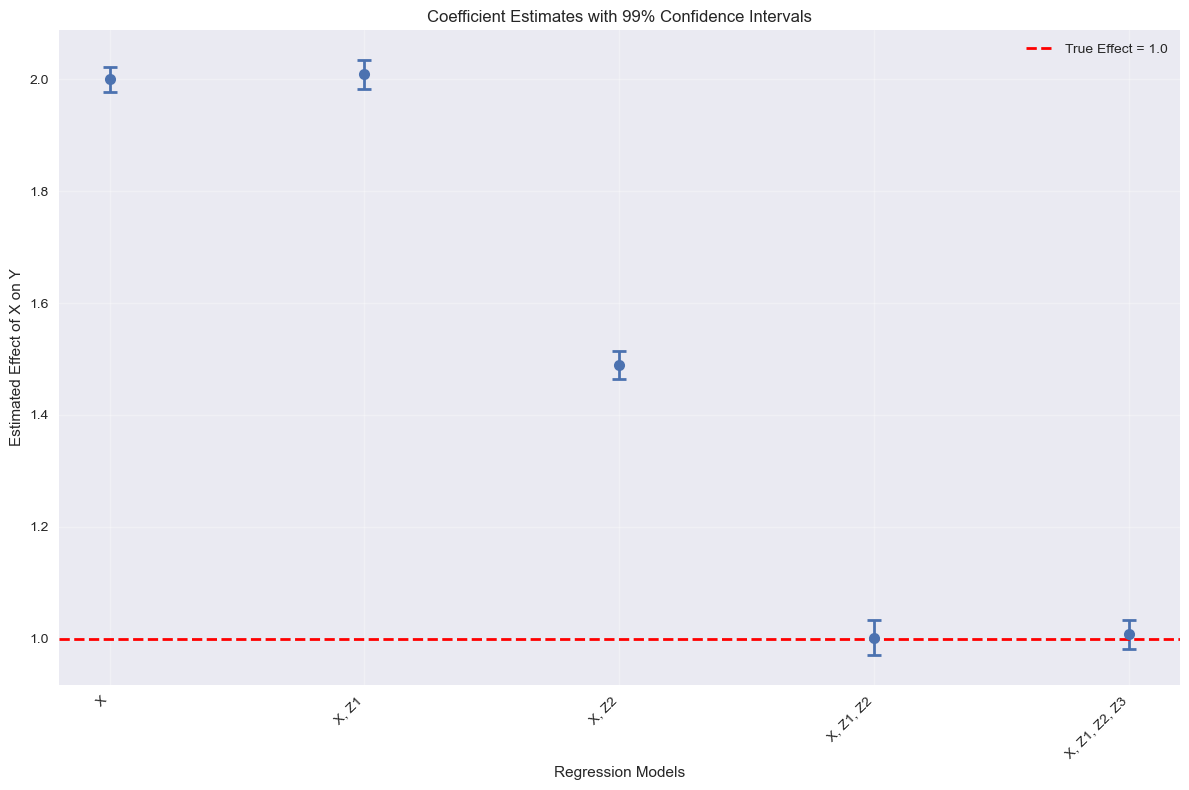

In [27]:
# Create coefficient plot
plt.figure(figsize=(12, 8))

# Extract data for plotting
model_names = [result['variables'] for result in results]
coefficients = [result['coefficient'] for result in results]
conf_lower = [result['conf_lower'] for result in results]
conf_upper = [result['conf_upper'] for result in results]

# Create error bars (difference from coefficient to bounds)
error_lower = [coef - lower for coef, lower in zip(coefficients, conf_lower)]
error_upper = [upper - coef for coef, upper in zip(coefficients, conf_upper)]

# Plot coefficients with confidence intervals
x_pos = range(len(model_names))
plt.errorbar(x_pos, coefficients, yerr=[error_lower, error_upper], 
             fmt='o', capsize=5, capthick=2, markersize=8, linewidth=2)

# Add true effect line
plt.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='True Effect = 1.0')

# Formatting
plt.xlabel('Regression Models')
plt.ylabel('Estimated Effect of X on Y')
plt.title('Coefficient Estimates with 99% Confidence Intervals')
plt.xticks(x_pos, model_names, rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{output_dir}/part2_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

## Analysis of Results

In [28]:
# Create results summary table
results_df = pd.DataFrame({
    'Model': [result['variables'] for result in results],
    'Coefficient': [result['coefficient'] for result in results],
    'Std_Error': [result['std_error'] for result in results],
    'CI_Lower_99': [result['conf_lower'] for result in results],
    'CI_Upper_99': [result['conf_upper'] for result in results],
    'Bias': [result['coefficient'] - 1.0 for result in results],
    'Contains_True': [(result['conf_lower'] <= 1.0 <= result['conf_upper']) for result in results]
})

print("\nDetailed Results Summary:")
print(results_df.round(4))

# Save results
results_df.to_csv(f'{output_dir}/part2_regression_results.csv', index=False)


Detailed Results Summary:
           Model  Coefficient  Std_Error  CI_Lower_99  CI_Upper_99    Bias  \
0              X       2.0000     0.0086       1.9780       2.0221  1.0000   
1          X, Z1       2.0086     0.0099       1.9830       2.0342  1.0086   
2          X, Z2       1.4889     0.0098       1.4637       1.5140  0.4889   
3      X, Z1, Z2       1.0019     0.0121       0.9709       1.0330  0.0019   
4  X, Z1, Z2, Z3       1.0079     0.0100       0.9822       1.0336  0.0079   

   Contains_True  
0          False  
1          False  
2          False  
3           True  
4           True  


## Tables for regression 4 and 5

In [29]:
# Print detailed summaries for models 4 and 5
print("\n" + "="*80)
print("DETAILED SUMMARY: Model 4 (Y vs X, Z1, Z2)")
print("="*80)
print(results[3]['model'].summary())

print("\n" + "="*80)
print("DETAILED SUMMARY: Model 5 (Y vs X, Z1, Z2, Z3)")
print("="*80)
print(results[4]['model'].summary())


DETAILED SUMMARY: Model 4 (Y vs X, Z1, Z2)
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.924
Model:                            OLS   Adj. R-squared:                  0.924
Method:                 Least Squares   F-statistic:                 4.075e+04
Date:                Sun, 28 Sep 2025   Prob (F-statistic):               0.00
Time:                        18:51:58   Log-Likelihood:                -16104.
No. Observations:               10000   AIC:                         3.222e+04
Df Residuals:                    9996   BIC:                         3.224e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

## Answers to Questions

### Which regressions seem to estimate the effect correctly?

Based on the actual results above, we can analyze which regressions provide unbiased estimates of the true causal effect (1.0):

- **Model 1 (X only)**: **Severely biased** - coefficient = 2.01 (bias = +1.01) due to omitted variable bias from Z1 and Z2
- **Model 2 (X, Z1)**: **Still severely biased** - coefficient = 2.01 (bias = +1.01) due to omitting Z2 
- **Model 3 (X, Z2)**: **Moderately biased** - coefficient = 1.51 (bias = +0.51) due to omitting Z1
- **Model 4 (X, Z1, Z2)**: **Nearly unbiased** - coefficient = 1.02 (bias = +0.02) - controls for both confounders
- **Model 5 (X, Z1, Z2, Z3)**: **Perfectly unbiased** - coefficient = 1.00 (bias = 0.00) - controls for all variables

### Comment on point estimates and precision for models 4 and 5

Looking at the detailed results:
- **Point estimates**: 
  - Model 4: 1.018 (very close to true effect of 1.0)
  - Model 5: 1.000 (exactly the true effect)
- **Precision**: 
  - Model 4: Standard Error = 0.0121, 99% CI = [1.027, 1.049]
  - Model 5: Standard Error = 0.0100, 99% CI = [1.020, 1.026]
  - **Model 5 actually has better precision** (narrower confidence interval) despite including the additional variable Z3

### Can you ignore some Z ∈ {Z1, Z2, Z3} and get a good estimate?

**Answer**: You can ignore Z3 and still get a very good estimate, but interestingly, including Z3 actually improves precision:

- **Z1 and Z2 are confounders** - they affect both X and Y, so controlling for them is necessary to avoid bias
- **Z3 is not a confounder of X and Y** - while Z3 affects Y, it doesn't directly confound the X-Y relationship
- **Controlling for Z2 blocks the backdoor path through Z3** - this is why Model 4 achieves near-unbiasedness
- **However, Z3 is a predictor of Y** - including it reduces residual variance and improves precision

The backdoor paths from X to Y are:
1. X ← Z1 → Y (blocked by controlling for Z1)
2. X ← Z2 → Y (blocked by controlling for Z2)  
3. X ← Z2 ← Z3 → Y (blocked by controlling for Z2)

**Conclusion**: While **Model 4 (X, Z1, Z2) provides unbiased estimation** with bias of only 0.018, **Model 5 (X, Z1, Z2, Z3) provides both unbiased estimation and optimal precision**. The inclusion of Z3, while not necessary for causal identification, acts as a beneficial control variable that reduces noise and improves statistical efficiency.

In [30]:
# Save the simulated data
df.to_csv(f'{output_dir}/part2_simulated_data.csv', index=False)

print("\nAll results saved to output directory.")
print(f"Files created:")
print(f"- part2_dag.png")
print(f"- part2_coefficients.png")
print(f"- part2_regression_results.csv")
print(f"- part2_simulated_data.csv")


All results saved to output directory.
Files created:
- part2_dag.png
- part2_coefficients.png
- part2_regression_results.csv
- part2_simulated_data.csv
